In [7]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
import matplotlib.pyplot as plt

In [8]:
from sklearn.datasets import load_wine

data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (142, 13)
Test size: (36, 13)


In [9]:
p1 = X_train[0]
p2 = X_train[1]

# a) Euclidean Distance
euclidean = np.sqrt(np.sum((p1 - p2)**2))
print("Euclidean Distance:", round(euclidean, 4))

# b) Manhattan Distance
manhattan = np.sum(np.abs(p1 - p2))
print("Manhattan Distance:", round(manhattan, 4))

# c) Minkowski Distance (p=3)
p = 3
minkowski = np.sum(np.abs(p1 - p2)**p)**(1/p)
print("Minkowski Distance (p=3):", round(minkowski, 4))

Euclidean Distance: 6.3917
Manhattan Distance: 17.1323
Minkowski Distance (p=3): 4.8873


In [10]:
for metric in ['euclidean', 'manhattan', 'minkowski']:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, knn.predict(X_train))
    test_acc  = accuracy_score(y_test,  knn.predict(X_test))
    print(f"{metric.capitalize():12} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

Euclidean    | Train Acc: 0.9859 | Test Acc: 0.9444
Manhattan    | Train Acc: 0.9859 | Test Acc: 0.9444
Minkowski    | Train Acc: 0.9859 | Test Acc: 0.9444


Optimal K: 8
Best Test Accuracy: 0.9722222222222222


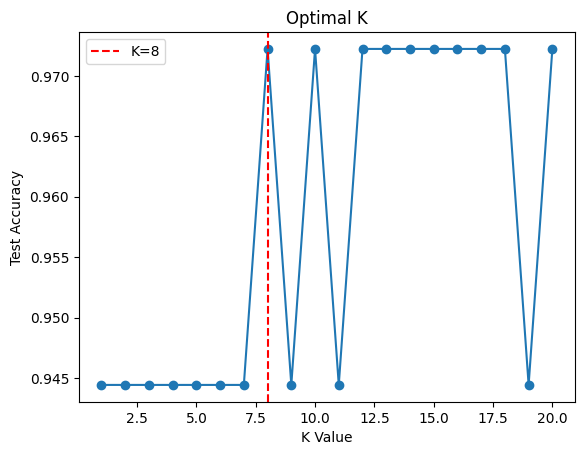

In [11]:
test_accs = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    test_accs.append(accuracy_score(y_test, knn.predict(X_test)))

optimal_k = k_range[np.argmax(test_accs)]
print("Optimal K:", optimal_k)
print("Best Test Accuracy:", max(test_accs))

plt.plot(k_range, test_accs, marker='o')
plt.xlabel("K Value")
plt.ylabel("Test Accuracy")
plt.title("Optimal K")
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'K={optimal_k}')
plt.legend()
plt.show()


In [12]:
knn_best = KNeighborsClassifier(n_neighbors=optimal_k)
knn_best.fit(X_train, y_train)
print("Train Accuracy (optimal K):", accuracy_score(y_train, knn_best.predict(X_train)))
print("Test Accuracy  (optimal K):", accuracy_score(y_test,  knn_best.predict(X_test)))


Train Accuracy (optimal K): 0.9788732394366197
Test Accuracy  (optimal K): 0.9722222222222222


In [13]:
knn_reg = KNeighborsRegressor(n_neighbors=optimal_k)
knn_reg.fit(X_train, y_train)

train_mse = mean_squared_error(y_train, knn_reg.predict(X_train))
test_mse  = mean_squared_error(y_test,  knn_reg.predict(X_test))

print("Regression Train MSE:", round(train_mse, 4))
print("Regression Test MSE: ", round(test_mse, 4))


Regression Train MSE: 0.0248
Regression Test MSE:  0.0226


In [14]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification, make_circles
from sklearn.metrics import accuracy_score

In [15]:
X, y = make_classification(n_samples=200, n_features=4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
print("Linear SVM (no explicit kernel)")
print("Train:", accuracy_score(y_train, svm_linear.predict(X_train)))
print("Test: ", accuracy_score(y_test,  svm_linear.predict(X_test)))


Linear SVM (no explicit kernel)
Train: 0.85625
Test:  0.925


In [17]:
X_nl, y_nl = make_circles(n_samples=200, noise=0.1, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_nl, y_nl, test_size=0.2, random_state=42)

svm_nonlinear = SVC(kernel='rbf')
svm_nonlinear.fit(X_tr, y_tr)
print("\nNon-Linear SVM (RBF on circular data)")
print("Train:", accuracy_score(y_tr, svm_nonlinear.predict(X_tr)))
print("Test: ", accuracy_score(y_te, svm_nonlinear.predict(X_te)))



Non-Linear SVM (RBF on circular data)
Train: 0.81875
Test:  0.8


In [18]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
print("Linear Kernel SVM")
print("Train:", accuracy_score(y_train, svm.predict(X_train)))
print("Test: ", accuracy_score(y_test,  svm.predict(X_test)))


Linear Kernel SVM
Train: 0.85625
Test:  0.925


In [19]:
kernels = {
    'Gaussian (rbf)':     SVC(kernel='rbf'),
    'Sigmoid':            SVC(kernel='sigmoid'),
    'Polynomial':         SVC(kernel='poly', degree=3),
}

for name, model in kernels.items():
    model.fit(X_train, y_train)
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    print(f"{name:25} | Train: {tr:.4f} | Test: {te:.4f}")

Gaussian (rbf)            | Train: 0.8875 | Test: 0.8750
Sigmoid                   | Train: 0.8375 | Test: 0.8250
Polynomial                | Train: 0.8250 | Test: 0.8000
